## Лабораторна робота №1 “Зменшення розмірності даних”  
#### **Мета**  
Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

### 1. Викачати та підготувати дані
+ Завантажити датасет за допомогою функції fetch_openml.
+ Вивести форму матриці X і кількість унікальних міток у y.
+ Для попереднього огляду візуалізувати кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


[68268 43567 42613 45891 21243 41993 55026 48600 39512 52620]


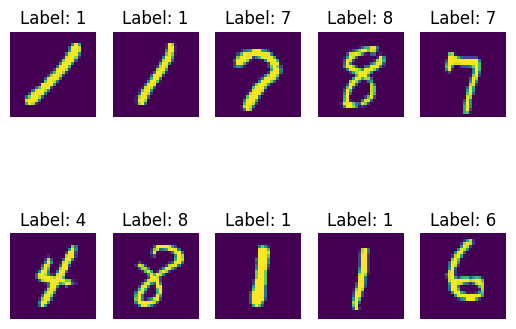

In [21]:
np.random.seed(0)
random_index = np.random.choice(X.shape[0], 10)
print(random_index)
for i, idx in enumerate(random_index):
    plt.subplot(2, 5, i + 1)  # 2 рядки по 5 зображень
    plt.imshow(X[idx].reshape(28, 28))  # перетворення вектора на рядок
    plt.title(f"Label: {y[idx]}")  
    plt.axis('off')   # без осей

plt.show()

### 2. Реалізувати метод головних компонент (PCA)
+ Реалізувати PCA із кількістю компонент n_components=3.
+ Отримати матрицю проєкцій (X_pca) розміром (70000 × 3);
+ Вивести відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_).


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"Розмір матриці проєкцій (X_pca): {X_pca.shape}")

Розмір матриці проєкцій (X_pca): (70000, 3)


In [23]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Пояснена дисперсія кожною компонентою:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"ГК{i+1}: {var:.3f} ({var*100:.1f}%) - Кумулятивна: {cum_var:.3f} ({cum_var*100:.1f}%)")


Пояснена дисперсія кожною компонентою:
ГК1: 0.056 (5.6%) - Кумулятивна: 0.056 (5.6%)
ГК2: 0.040 (4.0%) - Кумулятивна: 0.097 (9.7%)
ГК3: 0.037 (3.7%) - Кумулятивна: 0.134 (13.4%)


### 3. Візуалізувати дані у просторі перших трьох компонент
+ Побудувати 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використати matplotlib.axes3d або plotly). Точки зафарбувати відповідно до класу цифри.
+ Проаналізувати, чи видно кластери для різних цифр, наскільки добре PCA відділяє класи у тривимірному просторі.


In [24]:
import plotly.express as px
import pandas as pd

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['label'] = y.astype(int)

colors = ['red', 'green', 'blue', 'orange', 'lime', 'brown', 'cyan', 'magenta', 'yellow', 'black']

df_pca['label'] = df_pca['label'].astype('category')

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='label', 
                    color_discrete_map={i: colors[i] for i in range(10)},
                    title="PCA: 3D Plot of First Three Principal Components",
                    labels={'label': 'Digits'},
                    height=800)

fig.update_traces(marker=dict(size=2))

fig.update_layout(
    scene = dict(
        xaxis_title=f'ГК1: {explained_variance_ratio[0]:.3f} ({explained_variance_ratio[0]*100:.1f}%)',
        yaxis_title=f'ГК2: {explained_variance_ratio[1]:.3f} ({explained_variance_ratio[1]*100:.1f}%)',
        zaxis_title=f'ГК3: {explained_variance_ratio[2]:.3f} ({explained_variance_ratio[2]*100:.1f}%)',
    )
)
fig.show()

Для більшості цифр видно чітке відокремлення точок, особливо для 0, 1, 7 і 9. Однак деякі цифри (6 і 5, 2 і 3) мають певне накладення. Основна кількість точок зосереджена в одній частині графіка, що створює візуальне скупчення і ускладнює чітке виділення окремих груп. Деякі групи мають значну площу, що може призводити до їхнього перекриття з іншими групами. Це особливо помітно для цифр, таких як 5, 6, 8.

### 4. Реконструкція зображень після зменшення розмірності
+ Використати метод inverse_transform() з PCA для відновлення даних із простору трьох компонент у оригінальний простір.
+ Вивести кілька прикладів (наприклад, 10 випадкових цифр):  
    + оригінальне зображення;  
    + реконструйоване після PCA з трьома компонентами.


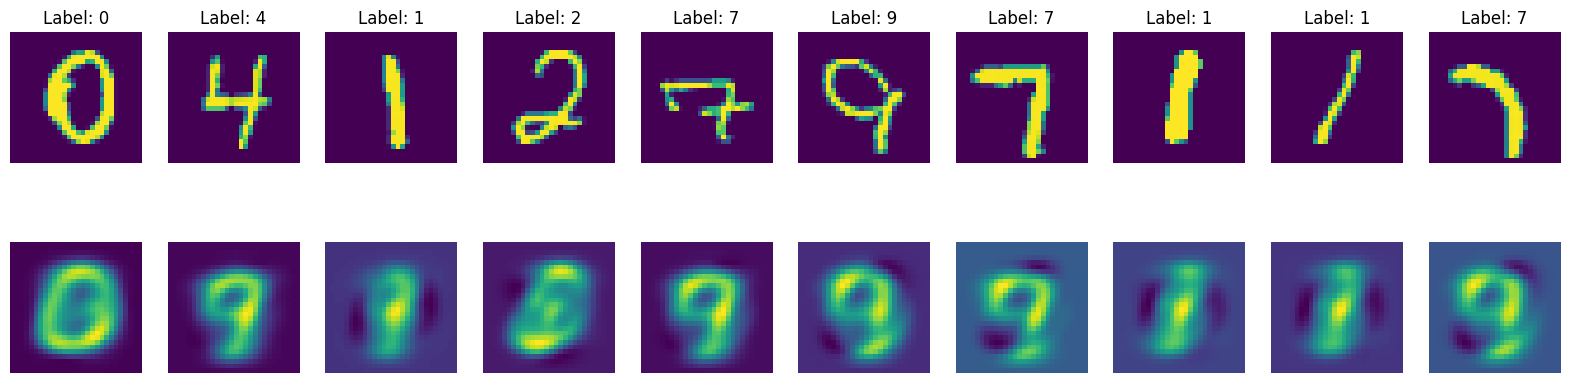

In [25]:
from sklearn.metrics import mean_squared_error
np.random.seed(0)
X_reconstructed = pca.inverse_transform(X_pca)
X_reconstructed_scaled = scaler.inverse_transform(X_reconstructed)
random_indices = np.random.choice(X.shape[0], 10, replace=False)
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, idx in enumerate(random_indices):
    # Оригінальне зображення
    axes[0, i].imshow(X[idx].reshape(28, 28))
    axes[0, i].set_title(f"Label: {y[idx]}") 
    axes[0, i].axis('off') 
    
    # Реконструйоване зображення
    axes[1, i].imshow(X_reconstructed_scaled[idx].reshape(28, 28))
    axes[1, i].axis('off') 

plt.show()

### 5. Проаналізувати залежність між помилкою реконструкції та кількістю компонент
+ Визначити помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями пікселів.
+ Обчислити MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k і побудувати відповідні графіки.

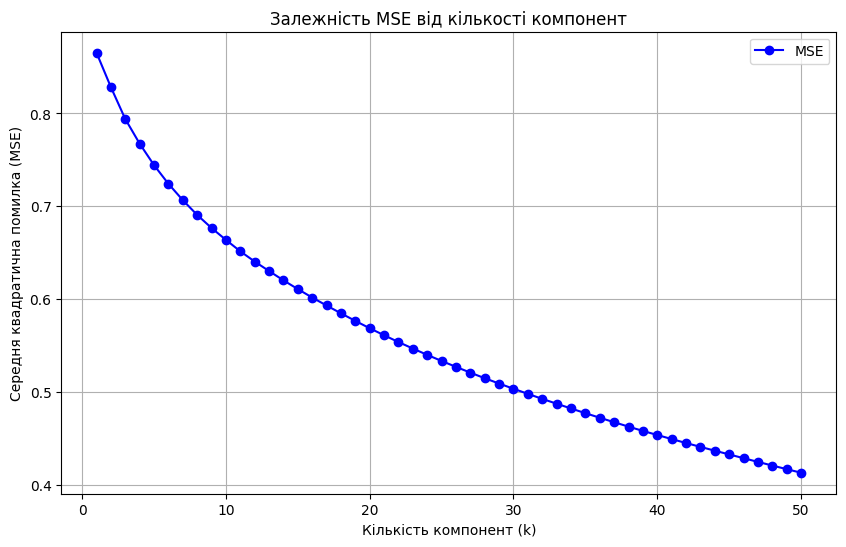

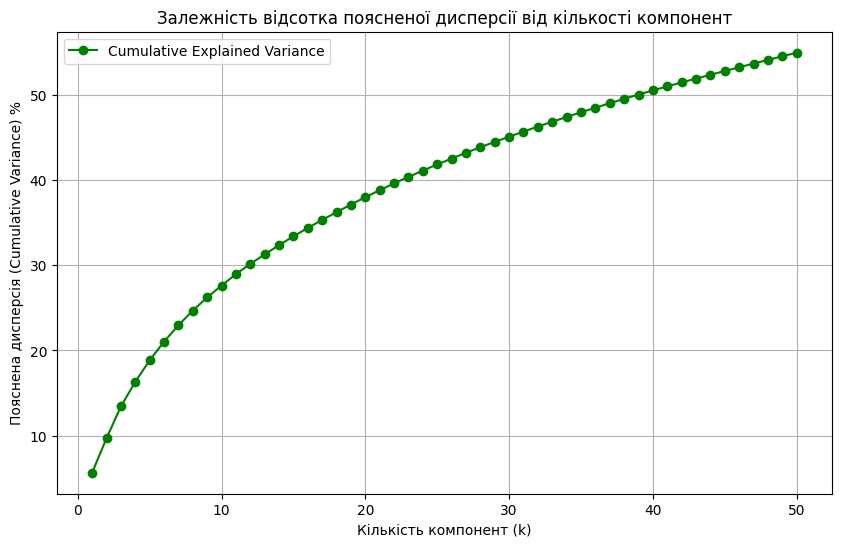

In [26]:
from sklearn.metrics import mean_squared_error

mse_values = []
explained_variance_ratios = []

for k in range(1, 51):  
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    
    X_reconstructed = pca.inverse_transform(X_pca)
    
    # MSE для відновлених даних
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_values.append(mse)
    
    explained_variance_ratios.append(np.sum(pca.explained_variance_ratio_) * 100)

# графік залежності MSE від кількості компонент
plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), mse_values, marker='o', color='blue', label='MSE')
plt.title('Залежність MSE від кількості компонент')
plt.xlabel('Кількість компонент (k)')
plt.ylabel('Середня квадратична помилка (MSE)')
plt.grid(True)
plt.legend()
plt.show()

# графік залежності поясненої дисперсії від кількості компонент

plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), explained_variance_ratios, marker='o', color='green', label='Cumulative Explained Variance')
plt.title('Залежність відсотка поясненої дисперсії від кількості компонент')
plt.xlabel('Кількість компонент (k)')
plt.ylabel('Пояснена дисперсія (Cumulative Variance) %')
plt.grid(True)
plt.legend()
plt.show()

### Висновок
У результаті виконаної роботи було встановлено, що пояснена дисперсія залишилася низькою (13.4%), оскільки ми зменшили кількість компонент з 784 до 3. Це не дозволяє зберегти достатньо інформації для точного відновлення даних. Графіки показали, як MSE зменшується з кількістю компонент, що підтверджує, що для досягнення кращих результатів реконструкції необхідно використовувати більше компонент.